# Random Sample Imputation



src: [Missing Indicator | Random Sample Imputation | Handling Missing Data Part 4](https://www.youtube.com/watch?v=Ratcir3p03w)

## 1. Random Sample Imputation for numerical data

In [28]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# Titanic dataset
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [30]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [31]:
df.isnull().mean() * 100

,0
Survived,0.00000
Age,19.86532
Fare,0.00000


---

### 📊 Output Interpretation:

```python
Survived     0.00000
Age         19.86532
Fare         0.00000
```

| Column     | Meaning                                            |
| ---------- | -------------------------------------------------- |
| `Survived` | No missing values (0% missing)                     |
| `Age`      | About **19.87%** of rows have missing `Age` values |
| `Fare`     | No missing values (0% missing)                     |

---

In [32]:
X = df.drop(columns=['Survived'])  # Drop the target column to keep only features
y = df['Survived']                 # Extract the target column (label) as y

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,               # Input features and target
    test_size=0.2,      # 20% of the data goes into the test set
    random_state=2      # Ensures reproducibility (same split every run)
)

In [34]:
X_train # Before adding new columns

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


### **Compare before and after imputation**

In [35]:
# Create a new column 'Age_imputed' to hold imputed values
# Initially, copy the original 'Age' values from train and test sets
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [36]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


### Random Imputation of Missing Age Values Using Training Set Distribution

We replace missing 'Age_imputed' values in both training and test sets with randomly sampled values from the original 'Age' column of the training set, while preserving reproducibility with a fixed seed.

### 🥡 Test code

In [37]:
# Step 1: Access the 'Age_imputed' column from the training dataset
# Step 2: Use .isnull() to check for missing (NaN) values
#         This returns a Series of True/False values:
#         - True  → the value is missing
#         - False → the value is present
# Step 3: Store the result in the variable 'missing_train_mask'
#         This variable acts like a "mask" — it marks which rows have missing values
missing_train_mask = X_train['Age_imputed'].isnull()
missing_train_mask
# When you print this, you'll see something like:
# 12     False
# 18      True
# 24     False
# ...
# Meaning: row 18 has a missing value in 'Age_imputed'


,Age_imputed
30,False
10,False
873,False
182,False
876,False
...,...
534,False
584,True
493,False
527,True


---

### ✅ Why This Is Useful

* You can use this mask later to **select only the rows with missing values**, like:

  ```python
  X_train.loc[missing_train_mask]
  ```
* It's commonly used when you're about to **fill missing values**, especially row-wise or conditionally.

---

### 🥡 Test code

In [38]:
# Step 1: Count how many values are missing in 'Age'
num_missing = X_train['Age'].isnull().sum()

# Step 2: Generate random imputed values from the available (non-null) values in 'Age'
random_ages = X_train['Age'].dropna().sample(
    n=num_missing,         # ➤ Number of values to sample = number of missing entries
    replace=True,          # ➤ Allows repeated values (needed if num_missing > unique values in Age)
    random_state=42        # ➤ Fixes the randomness so results are reproducible across runs
).values                   # ➤ Convert the sampled Series into a NumPy array for assignment

random_ages

array([36.  ,  4.  , 56.  , 42.  , 19.  , 24.  , 20.  ,  6.  , 24.  ,
       35.  , 16.  , 21.  , 37.  , 19.  , 21.  , 19.  , 39.  , 18.  ,
       11.  , 52.  , 25.  , 21.  , 45.  , 22.  , 17.  , 56.  , 48.  ,
       25.  ,  6.  , 21.  , 16.  , 29.  , 16.  , 30.  ,  1.  , 34.  ,
       21.  , 39.  , 24.  , 20.  , 24.  , 54.  , 52.  , 37.  , 40.  ,
       38.  , 30.5 ,  5.  , 32.  ,  4.  , 18.  , 13.  , 42.  , 52.  ,
       48.  , 50.  , 54.  ,  4.  , 40.5 , 16.  ,  3.  , 27.  , 60.  ,
        9.  , 22.  , 65.  , 56.  , 35.  , 20.  , 24.  , 22.  , 19.  ,
       24.  , 28.  , 32.  , 29.  , 25.  , 35.  , 24.  , 18.  ,  7.  ,
       33.  , 39.  , 22.  , 52.  , 31.  , 58.  , 24.  , 19.  , 21.  ,
       17.  , 21.  , 38.  , 36.  , 35.  , 50.  , 27.  , 30.  , 33.  ,
       19.  , 22.  , 62.  ,  4.  , 36.  , 20.  , 20.  , 19.  , 22.  ,
       29.  , 61.  , 33.  , 18.  ,  0.83, 22.  , 51.  , 71.  , 21.  ,
       39.  , 62.  , 36.  , 34.  , 64.  , 19.  , 26.  , 39.  , 53.  ,
       30.  , 27.  ,

In [39]:
# Step 1: Select the 'Age' column from the training dataset
# Step 2: Check which values are missing (NaN) using .isnull()
#         This returns True for missing values and False otherwise
# Step 3: Use .sum() to count how many True values there are — i.e., how many values are missing
X_train['Age'].isnull().sum() # 148 missing values

np.int64(148)

### Actual Implementation

In [40]:
# ----------------------------------------------
# Step 1: Create a mask for missing values
# ----------------------------------------------
missing_train_mask = X_train['Age_imputed'].isnull()
missing_test_mask = X_test['Age_imputed'].isnull()

# ----------------------------------------------
# Step 2: Randomly sample non-null Age values from training set
#         and assign them to the missing locations
# ----------------------------------------------

# For training set
X_train.loc[missing_train_mask, 'Age_imputed'] = (  # Step 1: Select the rows where 'Age_imputed' is missing
    X_train['Age'].dropna()                         # Step 2: Take the 'Age' column and drop all NaN (missing) values
    .sample(                                        # Step 3: Randomly sample values from the non-missing 'Age' data
        n=missing_train_mask.sum(),                 # ➤ Number of values to sample = number of missing values
        replace=True,                               # ➤ Allow repeated values if necessary (important for small datasets)
        random_state=42                             # ➤ Set a random seed for reproducibility (same result every run)
    )
    .values                                         # Step 4: Convert the result to a NumPy array for assignment
)

# For test set — also sample from training data's non-null values
X_test.loc[missing_test_mask, 'Age_imputed'] = (
    X_train['Age'].dropna()
    .sample(n=missing_test_mask.sum(), replace=True, random_state=42)
    .values
)


**Verify replacement by comparing Age and Age_imputed columns**

In [41]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,21.0
493,71.0,49.5042,71.0
527,NaN,221.7792,14.0


### Visual Comparison of Original and Imputed 'Age' Distributions

Check if Imputed 'Age' Values Preserve the Original Data Distribution

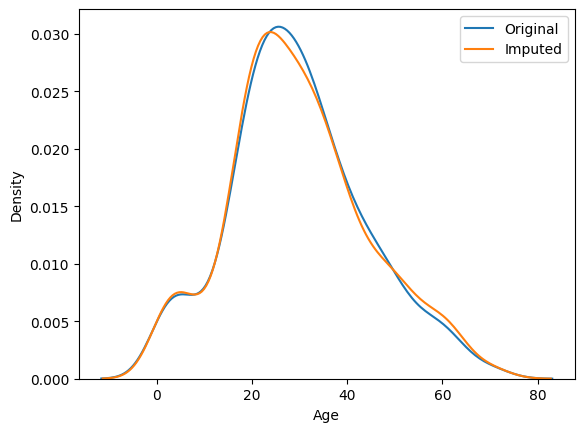

In [42]:
# Import seaborn for plotting smooth density curves (KDE plots)
import seaborn as sns

# Import matplotlib for general plotting functions
import matplotlib.pyplot as plt

# ---------------------------------------------
# Plotting the distribution of original 'Age'
# ---------------------------------------------

# Plot the distribution of the 'Age' column from training data
# This includes only non-missing values (NaN will be ignored automatically)
# 'kdeplot' draws a smooth curve to show the density (i.e., how values are spread out)
sns.kdeplot(X_train['Age'], label='Original')

# ---------------------------------------------
# Plotting the distribution after imputation
# ---------------------------------------------

# Plot the distribution of the 'Age_imputed' column
# This column has missing values filled in (e.g., via random imputation)
# We want to compare this to the original distribution
sns.kdeplot(X_train['Age_imputed'], label='Imputed')

# ---------------------------------------------
# Add legend to label the lines on the plot
# ---------------------------------------------

# Shows labels like 'Original' and 'Imputed' on the plot
plt.legend()

# Display the plot window with the curves
plt.show()

🧠 **Why Use This Plot?**

This visualization helps you:

* **Check if the imputed values preserve the original distribution**
* Validate that your imputation method (e.g., random imputation) didn't distort the shape of the data

---

---

✅ **Plot Interpretation**

> The plot **visually validates** that **random imputation preserves the shape** of the original `'Age'` distribution, making it a **great choice for linear models** when data has missing values.

> **In tree-based models, random imputation may introduce slight discrepancies in feature distributions, particularly when a large proportion of values are missing.**

> Since decision trees rely on threshold-based splitting rather than feature distribution, imputed values sampled randomly may lead to suboptimal or unstable splits. This can reduce model interpretability or slightly impact performance, especially if the randomness is not controlled (e.g., without fixed seed).

---

**🔎 Experiment**

1. Add a subplot comparing this with **mean or median imputation** to highlight the difference more clearly

---

### Comparing Variance and CoVariance

In [44]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.3495133904614
Variance after random imputation:  213.4914319276537


---

> **Random imputation preserves variance well**, as shown by the close match (204.35 → 213.49). This makes it a reliable imputation technique when using models that assume or benefit from stable feature distributions, such as **linear regression**.

---

We check the relationship of **Fare** with **Age** and compare that with **Age_Imputed** and **Fare**

In [45]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,47.898304
Age,71.512440,204.349513,204.349513
Age_imputed,47.898304,204.349513,213.491432


---

### ✅ Interpretation

#### 🔹 1. **Variance of Age and Age\_imputed**

* Diagonal values:

  * `Age`: **204.35**
  * `Age_imputed`: **213.49**
* These are close in value, indicating that **variance is preserved** after random imputation.
* ✅ Confirms what we saw earlier: random imputation retains feature spread.

#### 🔹 2. **Covariance between Age and Age\_imputed**

* Value: **204.35**
* This high covariance indicates that the imputed values in `'Age_imputed'` are **closely aligned** with the original non-missing `'Age'` values.
* 🔍 Suggests that imputation did not distort the structure of the original feature.

#### 🔹 3. **Covariance with another feature — `Fare`**

* `Fare vs Age`: **71.51**
* `Fare vs Age_imputed`: **47.90**

📌 **Transcript Insight**:

> "While random imputation preserves the feature’s own distribution, it can slightly distort its **relationship with other features**."

* The drop from **71.51 → 47.90** in covariance with `Fare` indicates:

  * The **relationship between Age and Fare got slightly disturbed** due to random imputation.
  * This is expected because random values are introduced **independently** — without considering correlations with other columns.

---

### 🚨 Summary of Key Takeaways

| Relationship                 | Covariance | Interpretation                                                    |
| ---------------------------- | ---------- | ----------------------------------------------------------------- |
| Age vs Age                   | 204.35     | Original variance of Age                                          |
| Age\_imputed vs Age\_imputed | 213.49     | Variance preserved after imputation                               |
| Age vs Age\_imputed          | 204.35     | ✅ Very strong alignment (as values are sampled from the original) |
| Age vs Fare                  | 71.51      | Original relationship                                             |
| Age\_imputed vs Fare         | 47.90      | ❗️Slight loss in correlation after imputation                     |

---

**⚠️ Instructor’s Caution:**

> **Random imputation preserves variance and distribution of individual features very well**, which makes it ideal for linear models.
> However, since it introduces values without considering feature-to-feature relationships, it can **weaken correlations** — as seen in the reduced covariance between `'Age_imputed'` and `'Fare'`.

> Use caution when using this technique in **models sensitive to inter-feature relationships**, or where **covariance is crucial**.

---

### Any Changes to Outliers due to Random Sample Imputation?

<Axes: >

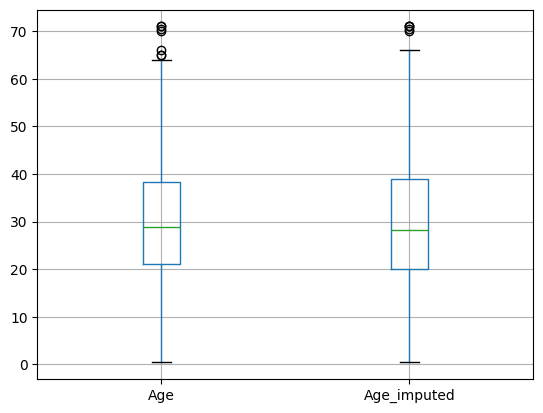

In [46]:
X_train[['Age', 'Age_imputed']].boxplot()

No major changes observed. Number of outliers for Age and Age_imputed are almost same

---

## 🎯 Problem in Production: Random Imputation Is Not Repeatable by Default

In production:

* If you use `.sample()` without a fixed `random_state`, each time the model runs, **a different random value** might be selected for the same missing feature (like `'Age'`).
* This means that **the same input can yield different predictions** each time it's scored — which is **undesirable and unstable**.
* Example: First for Fare = `$50`, you get Age = 25. Then next time when the same fare = `$50` is presented we should get the Age = 25 (deterministic instead of it being random). 2 users can be querying on the sample fare and random ages could lead to different results - which is a problem

---

## 🧠 Solution Shown in the Code

```python
random_state=int(observation['Fare'])
```

This sets the **random seed based on a value from the input data itself** (in this case, `observation['Fare']`), so:

* **Every time this row is processed**, it uses the **same seed**
* Therefore, the **same random imputed value** is selected
* ✅ **Predictability is preserved**, even though imputation is still random

---

## 📌 Summary

> In production, **random imputation must be made deterministic**.
> You can do this by deriving the `random_state` from some stable field in the input (like `Fare`, `PassengerID`, etc.), so that the **same observation always gets the same imputed value** — avoiding inconsistencies across model runs.

---

In [ ]:
# Deterministic Random Imputation
# sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

# see courses/3-dsmp-2.0-by-campusx/feature-engineering/999.38-Missing Indicator/2.2-Deterministic Random Imputation.md for an explanation

## 2. Random Sample Imputation for categorical data

In [67]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [68]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [69]:
print(data.isnull().mean() * 100)

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64


---

### 📊 Interpretation of Output:


| Column          | % Missing  | Interpretation                                                                                                                                                                                    |
| --------------- | ---------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **FireplaceQu** | **47.26%** | Nearly half the rows are missing this value. This is **significant** and may require **special treatment**, such as adding a missing indicator or using a model that can handle high missingness. |
| **GarageQual**  | **5.55%**  | A small portion of rows are missing this. Can be safely imputed (e.g., with mode or random sampling).                                                                                             |
| **SalePrice**   | **0.00%**  | No missing values at all — this is your **target variable**, so this is ideal and expected.                                                                                                       |

---

In [70]:
X = data
y = data['SalePrice']

In [71]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [72]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [73]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1322,TA,TA,190000,TA,TA
713,NaN,TA,129000,TA,NaN
81,NaN,TA,153500,TA,NaN
953,Po,TA,172000,TA,Po
914,NaN,TA,173733,TA,NaN


In [55]:
# X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
# X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

# X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
# X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

---

### 🧠 Code breakdown:

| Part                                       | Meaning                                                                                                        |
| ------------------------------------------ | -------------------------------------------------------------------------------------------------------------- |
| `X_train['GarageQual_imputed'].isnull()`   | Creates a **Boolean mask**: `True` for rows where `'GarageQual_imputed'` is missing (`NaN`), `False` otherwise |
| `X_train.loc[ ... , 'GarageQual_imputed']` | Selects only the **rows in `'GarageQual_imputed'` where the value is missing**                                 |

---

In [74]:
# ------------------------------------------------------------
# Randomly impute missing values in 'GarageQual_imputed' column (training set)
# ------------------------------------------------------------

# only the missing cells are updated
X_train.loc[X_train['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = (
    X_train['GarageQual']                    # Select the original 'GarageQual' column
    .dropna()                                # Drop all missing values so we only sample from valid data
    .sample(                                 # Randomly select values to fill in the missing ones
        n=X_train['GarageQual'].isnull().sum(),  # Sample as many values as there are missing (count of NaNs)
        replace=True,                            # Allow same value to be picked more than once if needed
        random_state=42                          # Set seed for reproducibility (same results every run)
    )
    .values                                   # Convert the sampled Series into a NumPy array for assignment
)

# ------------------------------------------------------------
# Randomly impute 'GarageQual_imputed' in test set using training set's distribution
# ------------------------------------------------------------

X_test.loc[X_test['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = (
    X_train['GarageQual']                    # Use only training data for sampling (avoid data leakage)
    .dropna()                                # Drop missing values to sample from clean data
    .sample(
        n=X_test['GarageQual'].isnull().sum(),   # Sample same number as missing in test set
        replace=True,
        random_state=42
    )
    .values
)

# ------------------------------------------------------------
# Randomly impute missing values in 'FireplaceQu_imputed' column (training set)
# ------------------------------------------------------------

X_train.loc[X_train['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = (
    X_train['FireplaceQu']
    .dropna()
    .sample(
        n=X_train['FireplaceQu'].isnull().sum(),
        replace=True,
        random_state=42
    )
    .values
)

# ------------------------------------------------------------
# Randomly impute 'FireplaceQu_imputed' in test set using training set's distribution
# ------------------------------------------------------------

X_test.loc[X_test['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = (
    X_train['FireplaceQu']
    .dropna()
    .sample(
        n=X_test['FireplaceQu'].isnull().sum(),
        replace=True,
        random_state=42
    )
    .values
)


In [76]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
262,TA,TA,151000,TA,TA
1012,TA,TA,165000,TA,TA
553,NaN,TA,108000,TA,TA
985,NaN,TA,125000,TA,Ex
957,NaN,TA,132000,TA,Po


---

> To evaluate the quality of imputation for categorical variables, we compare the **relative frequency distribution** of each category **before and after imputation**

> If the distribution changes significantly after imputation, it indicates that the process has introduced **bias or distortion**, which is generally **undesirable**.

> A good imputation technique should **preserve the original category proportions**, ensuring the statistical integrity of the feature remains intact.

---

In [77]:
# --------------------------------------------
# Step 1: Compare category distributions
#         Before and After Imputation
# --------------------------------------------

# Create a temporary DataFrame by combining two Series side-by-side using pd.concat()
temp = pd.concat(
    [
        # Left column: Relative frequency (proportion) of each category in the original column
        # Divide value counts by number of non-null entries (to ignore missing values)
        X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),

        # Right column: Relative frequency (proportion) in the imputed column
        # Divide by total number of rows (including previously missing ones)
        X_train['GarageQual_imputed'].value_counts() / len(X_train)
    ],
    axis=1  # Concatenate columns (side by side)
)

# Rename the columns of the new DataFrame for clarity
temp.columns = ['original', 'imputed']


In [79]:
temp

,original,imputed
TA,0.951043,0.950342
Fa,0.037171,0.036815
Gd,0.009973,0.011130
Po,0.000907,0.000856
Ex,0.000907,0.000856


---

### 🧠 Column Meaning:

| Column       | Explanation                                                                                          |
| ------------ | ---------------------------------------------------------------------------------------------------- |
| **original** | Proportion of each category in the original `GarageQual` column **(excluding missing values)**       |
| **imputed**  | Proportion of each category in the `GarageQual_imputed` column **(after filling in missing values)** |

---

### 🔍 Row-by-Row Interpretation:

| Category | `original` (%) | `imputed` (%) | Interpretation                                                                                                  |
| -------- | -------------- | ------------- | --------------------------------------------------------------------------------------------------------------- |
| TA       | 95.10%         | 95.03%        | Very little change — this is the **dominant category**, and the imputation preserved its proportion accurately. |
| Fa       | 3.72%          | 3.68%         | Almost unchanged — suggests random imputation selected Fa proportionally.                                       |
| Gd       | 0.997%         | 1.11%         | Slight increase — minor sampling variation, acceptable.                                                         |
| Po       | 0.0907%        | 0.0856%       | Almost identical — distribution preserved.                                                                      |
| Ex       | 0.0907%        | 0.0856%       | Also preserved — values are very close.                                                                         |

---

### ✅ What This Means

* The **category distribution after imputation closely matches** the original.
* This confirms that **random imputation using `.sample()` from the original pool preserved the proportions**.
* ✅ The imputation is **statistically faithful**, especially useful for models sensitive to category balance.

---

### 📌 Final Summary:

> **The imputed values reflect the original category distribution very well**, indicating that random sampling was successful in preserving the overall statistical profile of `GarageQual`.

---


The same technique is done for FireplaceQu where about 50% (47.260274) data was missing

In [82]:
# -------------------------------------------------------------
# Compare the category frequency distribution of FireplaceQu
# Before and After Imputation
# -------------------------------------------------------------

temp = pd.concat(
    [
        # Step 1: Calculate the relative frequency (proportion) of each category
        # in the original 'FireplaceQu' column (ignoring missing values)
        X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),

        # Step 2: Calculate the relative frequency (proportion) in the imputed column
        # This time, divide by total dataset length (df) to include all rows
        # This shows how imputation has influenced the overall distribution
        X_train['FireplaceQu_imputed'].value_counts() / len(df)
    ],
    axis=1  # Combine the two Series side by side (as columns)
)

# Rename the columns to indicate before and after imputation
temp.columns = ['original', 'imputed']

# Show the result
temp

,original,imputed
Gd,0.494272,0.641975
TA,0.412439,0.547699
Fa,0.040917,0.050505
Po,0.027823,0.042649
Ex,0.024550,0.028058


In [83]:
print(temp)

    original   imputed
Gd  0.494272  0.641975
TA  0.412439  0.547699
Fa  0.040917  0.050505
Po  0.027823  0.042649
Ex  0.024550  0.028058


---

### 📌 Interpretation:

> The instructor says:
> *"We compare the frequency before and after imputation. If there are changes, it is considered not good."*

---

### ✅ Applying That Guidance:

* For category **Gd**:

  * **Before**: 49.43%
  * **After**: 64.20%
  * 🔴 **Significant increase** — not good

* For category **TA**:

  * **Before**: 41.24%
  * **After**: 54.77%
  * 🔴 Also increased — not good

* Other categories (**Fa**, **Po**, **Ex**) show smaller changes, but still upward shifts.

---

### ❌ Conclusion (as per transcript):

> These shifts in distribution indicate that the **imputation changed the frequency balance of categories**.
> According to the instructor, this is **not good** — because a good imputation method should **preserve the original category distribution**.

---

In [80]:
print(temp)

    original   imputed
TA  0.951043  0.950342
Fa  0.037171  0.036815
Gd  0.009973  0.011130
Po  0.000907  0.000856
Ex  0.000907  0.000856


---

### 📌 Interpretation:

> The instructor says:
> *"We compare the frequency before and after imputation. If there are changes, it is considered not good."*

---

### ✅ Applying That Guidance:

* For category **Gd**:

  * **Before**: 49.43%
  * **After**: 64.20%
  * 🔴 **Significant increase** — not good

* For category **TA**:

  * **Before**: 41.24%
  * **After**: 54.77%
  * 🔴 Also increased — not good

* Other categories (**Fa**, **Po**, **Ex**) show smaller changes, but still upward shifts.

---

### ❌ Conclusion (as per transcript):

> These shifts in distribution indicate that the **imputation changed the frequency balance of categories**.

> According to the instructor, this is **not good** — because a good imputation method should **preserve the original category distribution**.

---


In [60]:
# for category in X_train['FireplaceQu'].dropna().unique():
#     sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
# plt.show()

## Comparing the Distribution for FireplaceQu before and after imputation

---

* **Compare the distribution of SalePrice across categories before and after imputation.**
* If the **patterns (shapes, positions, and spreads)** of the curves **change significantly**, then the imputation **has distorted the relationship** between the variable and the target (`SalePrice`).
* That is considered **not good**, because the imputed values are introducing **bias**.

---

### 📊 Applying that to Your Plots:

#### 🔹 **Before Imputation (Original `FireplaceQu`)**

* Each category (`TA`, `Fa`, `Gd`, `Ex`, `Po`) has a **distinct distribution curve** with **visible separation**.
* Example: `Ex` peaks at a **higher `SalePrice`**, `Po` and `Fa` at lower prices — this is expected and shows that `FireplaceQu` is meaningful.

#### 🔹 **After Imputation (`FireplaceQu_imputed`)**

* The curves are now more **smeared**, overlapping more.
* Categories like `Po`, `Fa`, and `Gd` have **shifts or tighter peaks**.
* **Discrepancies** suggest that imputation **has altered the original signal** (the relationship between `FireplaceQu` and `SalePrice`).

---

### ❌ Instructor’s Suggested Conclusion:

> Since the **category-level distributions of `SalePrice` have changed** after imputation, this is a sign that **random imputation may have distorted the relationship** between `FireplaceQu` and the target variable.
> According to the instructor, **this is not good**, especially if you plan to use this variable in a predictive model.

Let me know if you want to visualize the *difference in mean SalePrice per category* before and after imputation for further confirmation.


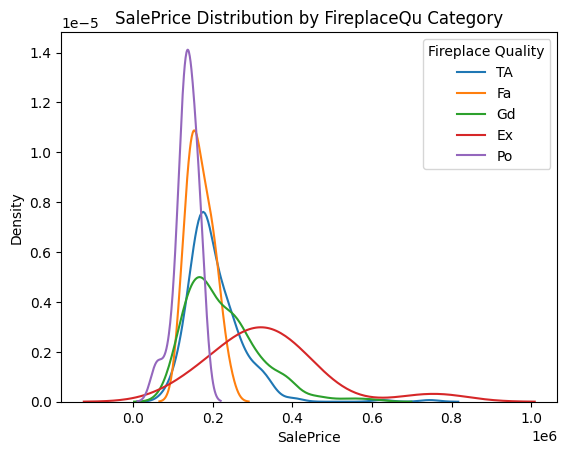

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the KDE of SalePrice for each category in FireplaceQu (ignoring missing values)
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(
        data=X_train[X_train['FireplaceQu'] == category],
        x='SalePrice',
        label=category,
        fill=False  # Optional: True to fill under the curve
    )

# Add legend and show the plot
plt.legend(title='Fireplace Quality')
plt.title('SalePrice Distribution by FireplaceQu Category')
plt.xlabel('SalePrice')
plt.ylabel('Density')
plt.show()

In [62]:
# for category in X_train['FireplaceQu_imputed'].dropna().unique():
#     sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
# plt.show()

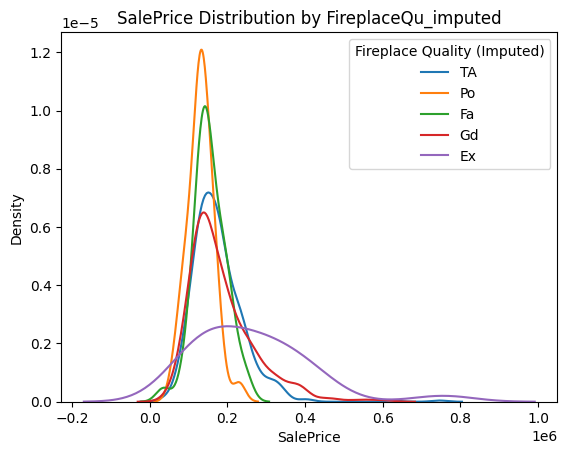

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of SalePrice for each category in FireplaceQu_imputed
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    # Filter rows that belong to the current category
    subset = X_train[X_train['FireplaceQu_imputed'] == category]

    # Plot KDE (smooth curve) for SalePrice
    sns.kdeplot(
        data=subset,
        x='SalePrice',
        label=category,
        fill=False  # Set to True if you want filled area under the curve
    )

# Add legend and axis labels
plt.legend(title='Fireplace Quality (Imputed)')
plt.title('SalePrice Distribution by FireplaceQu_imputed')
plt.xlabel('SalePrice')
plt.ylabel('Density')
plt.show()

### 📊 What we learn from above 2 Plots:

#### 🔹 **Before Imputation (Original `FireplaceQu`)**

* Each category (`TA`, `Fa`, `Gd`, `Ex`, `Po`) has a **distinct distribution curve** with **visible separation**.
* Example: `Ex` peaks at a **higher `SalePrice`**, `Po` and `Fa` at lower prices — this is expected and shows that `FireplaceQu` is meaningful.

#### 🔹 **After Imputation (`FireplaceQu_imputed`)**

* The curves are now more **smeared**, overlapping more.
* Categories like `Po`, `Fa`, and `Gd` have **shifts or tighter peaks**.
* **Discrepancies** suggest that imputation **has altered the original signal** (the relationship between `FireplaceQu` and `SalePrice`).

---

### ❌ Conclusion:

> Since the **category-level distributions of `SalePrice` have changed** after imputation, this is a sign that **random imputation may have distorted the relationship** between `FireplaceQu` and the target variable.

> According to the instructor, **this is not good**, especially if you plan to use this variable in a predictive model.

---

---

**Use of this column (`FireplaceQu`) in linear models after random imputation**:

> 🔹 "If the relationship between the imputed column and the target variable (`SalePrice`) changes after imputation, that’s a **problem for linear models**."

---

### 💡 Why?

* **Linear models** (like Linear Regression) assume a **consistent, linear relationship** between features and the target.
* If random imputation **distorts the distribution** (as seen in your second plot), then the model might **learn a misleading relationship**.
* Especially for **ordinal or categorical variables like `FireplaceQu`**, random sampling can **break the ordinal ranking**, causing **noisy coefficients**.

---

### 📌 Instructor's Implied Recommendation:

> 🔸 **Don’t blindly use `FireplaceQu_imputed` in linear models** without first checking if its relationship with the target (e.g., SalePrice) is preserved after imputation.

> 🔸 If distortion is visible (like in your plot), the column should be **carefully transformed, dropped**, or **handled differently** (e.g., with a missing indicator or using better imputation).

---

